# Output for ParaView: heat flow in a plate with a hole

We solve the heat equation in a plate with a hole, kept hot at the hole and cold on the outside, and write the temperature and the heat flux to VTK files for [ParaView](https://www.paraview.org), one file per output time and a collection file for the time slider.

$$u_t = k\,\Delta u \quad \text{in } \Omega = (0, 2) \times (0, 1) \text{ minus a disk}, \qquad u = 1 \text{ on the hole}, \qquad u = 0 \text{ on the outer boundary},$$

with $k = 0.1$ and $u = 0$ at $t = 0$. The heat flux is $q = -k\,\nabla u$. The files go to the folder `output`.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import femd as fd
from femd import dot, grad, dx

os.makedirs("output", exist_ok=True)

**The mesh.** `fd.triangulate` marks the outer boundary 1 and the hole 2. The hole is a polygon with 40 sides. We write the mesh alone to `plate_mesh.vtu`, with the boundary sides as line cells carrying their markers, to check in ParaView which marker is where.

511 vertices, 894 triangles, side markers [1, 2]


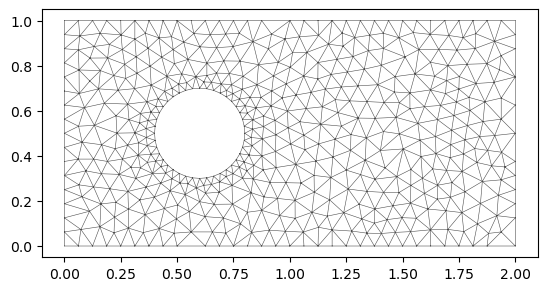

output/plate_mesh.vtu


In [2]:
m = fd.triangulate([(0, 0), (2, 0), (2, 1), (0, 1)], holes=[fd.circle(0.6, 0.5, 0.2, 40)],
                   min_angle=30, max_area=4e-3, smooth=20)
print(m.npoints, "vertices,", m.ntriangles, "triangles, side markers", sorted(set(np.asarray(m.segment_markers).tolist())))
m.plot()
plt.show()

print(fd.write_vtk("output/plate_mesh.vtu", mesh=m))

**The heat equation.** $P_2$ elements with the temperature built in on both boundaries, $u = 0$ on side 1 and $u = 1$ on side 2. In weak form $(u_t, v) = -k\,(\nabla u, \nabla v)$, a system $M c' = f(c)$ that `fd.IRK` advances with the two-stage Radau IIA method. The unknown `w` is a Function of `V.unconstrained`, which holds the boundary values. Its name, `"temperature"`, is the name of the array in the VTK files.

The heat flux $q = -k\,\nabla u$ is projected onto the vector space $P_2^2$, a Function named `"heat_flux"`.

In [3]:
k = 0.1
V = fd.LagrangeSpace(m, 2, dirichlet={1: 0.0, 2: 1.0})
u, v = fd.TrialFunction(V), fd.TestFunction(V)
w = fd.Function(V.unconstrained, "temperature")

dt = 0.02
irk = fd.IRK(fd.form(u * v * dx), fd.form(-k * dot(grad(w), grad(v)) * dx), dt, "radau", 2)

Q = fd.VectorFunctionSpace(m, 2)
q = fd.Function(Q, "heat_flux")

## Writing the files

`fd.VTKSeries("output/heat.pvd")` collects a time series. Each `series.write(t, ...)` writes one file, `heat_000000.vtu`, `heat_000001.vtu`, ..., and rewrites the collection `heat.pvd`, which lists the files with their times. A run that stops early still leaves a readable series.

The fields are written on VTK's quadratic Lagrange triangles, so ParaView draws the $P_2$ polynomial of every cell rather than a linear interpolation between the vertices. We write every $0.1$ time units up to $t = 2$, and the final state also to a single file, `heat_final.vtu`.

In [4]:
series = fd.VTKSeries("output/heat.pvd")
series.write(0.0, w, q)
for n in range(1, 101):
    irk.step(w)
    if n % 5 == 0:
        q.vector[:] = Q.project(-k * grad(w))
        series.write(round(n * dt, 10), w, q)          # the time, without round-off digits
print(series)
print(fd.write_vtk("output/heat_final.vtu", w, q))

VTKSeries('output/heat.pvd', 21 files)
output/heat_final.vtu


A quick look with matplotlib at $t = 2$. The heat has spread from the hole into the plate, and the flux points away from the hole, strongest at its edge.

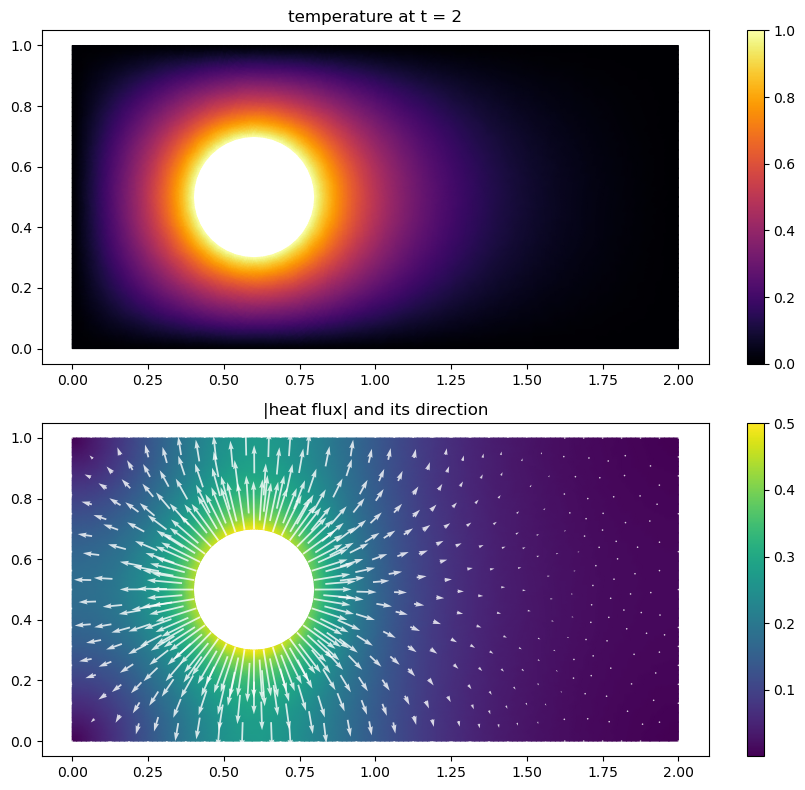

In [5]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
w.plot(axs[0], refine=4, cmap="inferno")
axs[0].set_title("temperature at t = 2")
q.plot(axs[1], refine=4, cmap="viridis")
axs[1].set_title("|heat flux| and its direction")
plt.tight_layout()
plt.show()

## In ParaView

1. **File > Open** `output/plate_mesh.vtu`, **Apply**, and colour by `marker`. The outer boundary is 1, the hole 2, and the triangles 0. The representation **Surface With Edges** shows the triangles.
2. **File > Open** `output/heat.pvd` (the collection, not the single files) and **Apply**. Colour by `temperature` and press **Play** to watch the heat spread from the hole. **Rescale to data range over all timesteps** (one of the buttons next to the colour map) keeps the colours fixed during the run.
3. The cells are quadratic. In the **Properties** panel (the gear icon shows the advanced options) set **Nonlinear Subdivision Level** to 2 or 3 for a smooth picture. At 1 each cell is drawn with straight edges between its nodes.
4. **Filters > Glyph** on `heat_flux` draws the flux as arrows, and **Filters > Contour** on `temperature` gives the isotherms.
5. `output/heat_final.vtu` is the last state alone, to open without the time series.